In [21]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from scipy.sparse import hstack
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
data = pd.read_csv("training.csv")   # your file
print(data.head())
print(data.columns)

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3
Index(['text', 'label'], dtype='object')


0 → Sad
1 → Happy
2 → Love (remove)
3 → Angry
4 → Fear
5 → Surprise (remove)

In [23]:
allowed_labels = [0, 1, 3, 4]
data = data[data["label"].isin(allowed_labels)].copy()

In [24]:
label_map = {
    1: 0,  # Happy
    0: 1,  # Sad
    3: 2,  # Angry
    4: 3   # Fear
}

data["label"] = data["label"].replace(label_map).astype(int)

In [25]:
print(data["label"].value_counts())

label
0    5362
1    4666
2    2159
3    1937
Name: count, dtype: int64


In [26]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

data["clean_text"] = data["text"].apply(clean_text)

In [ ]:
happy_words = ["happy","joy","smile","excited","cheerful"]
sad_words = ["sad","cry","lonely","depressed","down"]
angry_words = ["angry","hate","furious","rage","annoyed"]
fear_words = ["afraid", "scared", "nervous", "worried", "anxious",
 "uneasy", "panic", "terrified", "uncertain", 
 "heart racing", "something might go wrong", "fear of"]

def lexicon_features(text):
    words = text.split()
    return [
        sum(w in happy_words for w in words),
        sum(w in sad_words for w in words),
        sum(w in angry_words for w in words),
        sum(w in fear_words for w in words)
    ]

lex_df = pd.DataFrame(
    data["clean_text"].apply(lexicon_features).tolist(),
    columns=["happy_count","sad_count","angry_count","fear_count"]
)

In [28]:
tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(data["clean_text"])

In [29]:
X = hstack([X_tfidf, lex_df])
y = data["label"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [31]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.7794690265486726
              precision    recall  f1-score   support

           0       0.76      0.95      0.85      1073
           1       0.77      0.89      0.82       933
           2       0.88      0.44      0.59       432
           3       0.85      0.42      0.57       387

    accuracy                           0.78      2825
   macro avg       0.81      0.68      0.71      2825
weighted avg       0.79      0.78      0.76      2825



In [32]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.912212389380531
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1073
           1       0.93      0.90      0.91       933
           2       0.86      0.88      0.87       432
           3       0.87      0.89      0.88       387

    accuracy                           0.91      2825
   macro avg       0.90      0.90      0.90      2825
weighted avg       0.91      0.91      0.91      2825



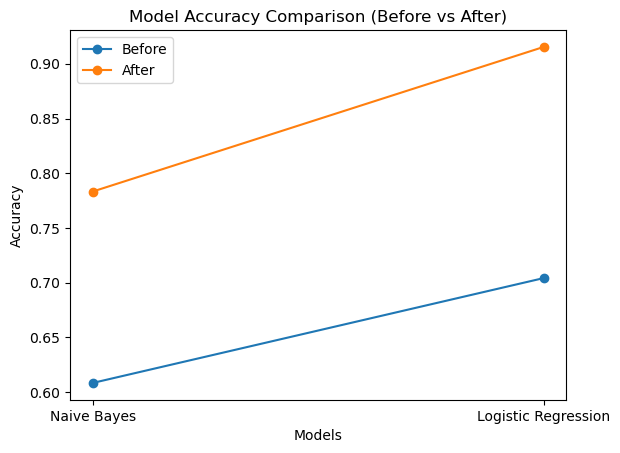

In [33]:
models = ["Naive Bayes", "Logistic Regression"]

before = [0.6084, 0.7042]
after = [0.7833, 0.9154]

x = range(len(models))

plt.figure()
plt.plot(x, before, marker='o', label="Before")
plt.plot(x, after, marker='o', label="After")

plt.xticks(x, models)
plt.title("Model Accuracy Comparison (Before vs After)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("accuracy_comparison.png")
plt.show()

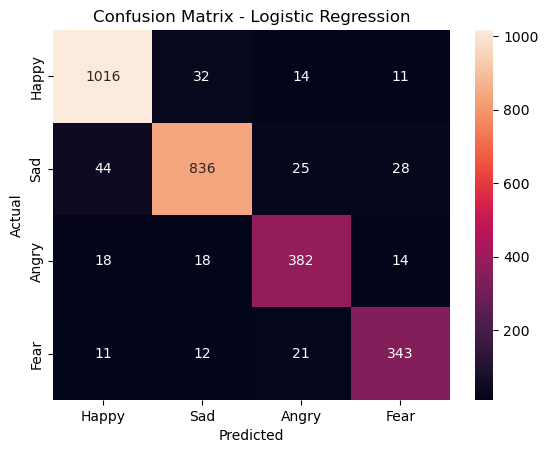

In [34]:
cm = confusion_matrix(y_test, lr.predict(X_test))

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Happy","Sad","Angry","Fear"],
            yticklabels=["Happy","Sad","Angry","Fear"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.savefig("confusion_matrix.png")
plt.show()

In [35]:
emotion_labels = {
    0: "Happy",
    1: "Sad",
    2: "Angry",
    3: "Fear"
}

In [36]:
def predict_emotion(text):
    cleaned = clean_text(text)
    text_tfidf = tfidf.transform([cleaned])
    lex_feat = lexicon_features(cleaned)
    final_features = hstack([text_tfidf, lex_feat])
    
    prediction = lr.predict(final_features)[0]
    
    return emotion_labels[int(prediction)]

In [37]:
import pickle

pickle.dump(lr, open("model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))
